In [1]:
# import numpy as np
# import pandas as pd
# import xgboost as xgb
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import brier_score_loss
# import warnings

# warnings.filterwarnings("ignore")

# DATA_PATH = "/kaggle/input/competitions/march-machine-learning-mania-2025/"
# CLIP_LOW, CLIP_HIGH = 0.05, 0.95

# def prepare_data_integrated(df):
#     dfswap = df[['Season','DayNum','LTeamID','LScore','WTeamID','WScore','WLoc','NumOT',
#                  'LFGM','LFGA','LFGM3','LFGA3','LFTM','LFTA','LOR','LDR','LAst','LTO','LStl','LBlk','LPF',
#                  'WFGM','WFGA','WFGM3','WFGA3','WFTM','WFTA','WOR','WDR','WAst','WTO','WStl','WBlk','WPF']].copy()
#     dfswap.loc[df['WLoc']=='H','WLoc']='A'
#     dfswap.loc[df['WLoc']=='A','WLoc']='H'
#     df.columns = [x.replace('W','T1_').replace('L','T2_') if x not in ['Season','DayNum','WLoc'] else x for x in df.columns]
#     dfswap.columns = [x.replace('L','T1_').replace('W','T2_') if x not in ['Season','DayNum','WLoc'] else x for x in dfswap.columns]
#     df.rename(columns={'WLoc':'location'}, inplace=True)
#     dfswap.rename(columns={'WLoc':'location'}, inplace=True)
#     output = pd.concat([df, dfswap]).reset_index(drop=True)
#     output['location'] = output['location'].map({'N':0,'H':1,'A':-1}).astype(int)
#     output['T1_Poss'] = output['T1_FGA'] + 0.475*output['T1_FTA'] - output['T1_OR'] + output['T1_TO']
#     output['T2_Poss'] = output['T2_FGA'] + 0.475*output['T2_FTA'] - output['T2_OR'] + output['T2_TO']
#     output['T1_eFG'] = (output['T1_FGM'] + 0.5*output['T1_FGM3']) / output['T1_FGA']
#     output['T2_eFG'] = (output['T2_FGM'] + 0.5*output['T2_FGM3']) / output['T2_FGA']
#     output['T1_TOR'] = output['T1_TO'] / output['T1_Poss']
#     output['T2_TOR'] = output['T2_TO'] / output['T2_Poss']
#     output['T1_OffRating'] = 100 * (output['T1_Score'] / output['T1_Poss'])
#     output['T2_OffRating'] = 100 * (output['T2_Score'] / output['T2_Poss'])
#     output['PointDiff'] = output['T1_Score'] - output['T2_Score']
#     return output

# def team_quality_fast(season, df):
#     data = df[df.Season == season]
#     teams = pd.concat([data.T1_TeamID, data.T2_TeamID]).unique()
#     team_index = {team:i for i,team in enumerate(teams)}
#     X = np.zeros((len(data), len(teams)))
#     y = (data.PointDiff > 0).astype(int).values
#     for i,row in enumerate(data.itertuples()):
#         X[i, team_index[row.T1_TeamID]] = 1
#         X[i, team_index[row.T2_TeamID]] = -1
#     model = LogisticRegression(penalty='l2', fit_intercept=False, max_iter=500)
#     model.fit(X,y)
#     return pd.DataFrame({'Season':season,'TeamID':teams,'quality':model.coef_[0]})

# def cauchyobj(preds, dtrain):
#     labels = dtrain.get_label()
#     c = 2.0
#     x = preds - labels
#     grad = x / (1 + (x/c)**2)
#     hess = 1 / (1 + (x/c)**2)
#     return grad, hess

# tourney_results = pd.concat([
#     pd.read_csv(DATA_PATH+"MNCAATourneyDetailedResults.csv"),
#     pd.read_csv(DATA_PATH+"WNCAATourneyDetailedResults.csv")
# ], ignore_index=True)

# regular_results = pd.concat([
#     pd.read_csv(DATA_PATH+"MRegularSeasonDetailedResults.csv"),
#     pd.read_csv(DATA_PATH+"WRegularSeasonDetailedResults.csv")
# ], ignore_index=True)

# seeds = pd.concat([
#     pd.read_csv(DATA_PATH+"MNCAATourneySeeds.csv"),
#     pd.read_csv(DATA_PATH+"WNCAATourneySeeds.csv")
# ], ignore_index=True)

# regular_data = prepare_data_integrated(regular_results)
# tourney_data = prepare_data_integrated(tourney_results)
# tourney_data = tourney_data[tourney_data.Season >= 2010].copy()

# team_stats = regular_data.groupby(['Season','T1_TeamID'])[['T1_eFG','T1_TOR','T1_OffRating']].mean().reset_index()
# team_stats.columns = ['Season','TeamID','eFG','TOR','OffRating']

# last14 = regular_data[regular_data.DayNum > 118].copy()
# last14['win'] = (last14.PointDiff > 0).astype(int)
# momentum = last14.groupby(['Season','T1_TeamID'])['win'].mean().reset_index()
# momentum.columns = ['Season','TeamID','win_ratio_14d']

# seeds['seed'] = seeds['Seed'].str[1:3].astype(int)
# seeds = seeds[['Season','TeamID','seed']]

# season_groups = dict(tuple(regular_data.groupby('Season')))
# glm_quality = pd.concat([team_quality_fast(season, season_groups[season]) for season in sorted(regular_data.Season.unique())]).reset_index(drop=True)

# def master_merge(df):
#     df = df.copy()
#     df = df.merge(team_stats.rename(columns={'TeamID':'T1_TeamID','eFG':'T1_eFG','TOR':'T1_TOR','OffRating':'T1_OffRating'}), on=['Season','T1_TeamID'], how='left')
#     df = df.merge(team_stats.rename(columns={'TeamID':'T2_TeamID','eFG':'T2_eFG','TOR':'T2_TOR','OffRating':'T2_OffRating'}), on=['Season','T2_TeamID'], how='left')
#     df = df.merge(glm_quality.rename(columns={'TeamID':'T1_TeamID','quality':'T1_quality'}), on=['Season','T1_TeamID'], how='left')
#     df = df.merge(glm_quality.rename(columns={'TeamID':'T2_TeamID','quality':'T2_quality'}), on=['Season','T2_TeamID'], how='left')
#     df = df.merge(seeds.rename(columns={'TeamID':'T1_TeamID','seed':'T1_seed'}), on=['Season','T1_TeamID'], how='left')
#     df = df.merge(seeds.rename(columns={'TeamID':'T2_TeamID','seed':'T2_seed'}), on=['Season','T2_TeamID'], how='left')
#     df = df.merge(momentum.rename(columns={'TeamID':'T1_TeamID','win_ratio_14d':'T1_win_ratio_14d'}), on=['Season','T1_TeamID'], how='left')
#     df = df.merge(momentum.rename(columns={'TeamID':'T2_TeamID','win_ratio_14d':'T2_win_ratio_14d'}), on=['Season','T2_TeamID'], how='left')
#     df['Seed_diff'] = df['T1_seed'] - df['T2_seed']
#     df['diff_quality'] = df['T1_quality'] - df['T2_quality']
#     required = ['T1_seed','T2_seed','Seed_diff','T1_quality','T2_quality','diff_quality',
#                 'T1_eFG','T1_TOR','T1_OffRating','T2_eFG','T2_TOR','T2_OffRating',
#                 'T1_win_ratio_14d','T2_win_ratio_14d']
#     for col in required:
#         if col not in df.columns:
#             df[col] = 0
#     return df.fillna(0)

# tourney_data = master_merge(tourney_data)

# features = ['T1_seed','T2_seed','Seed_diff','T1_quality','T2_quality','diff_quality',
#             'T1_eFG','T1_TOR','T1_OffRating','T2_eFG','T2_TOR','T2_OffRating',
#             'T1_win_ratio_14d','T2_win_ratio_14d']

# param = {'eta':0.01,'max_depth':4,'subsample':0.8,'colsample_bytree':0.8,'eval_metric':'rmse'}

# all_seasons = sorted(tourney_data.Season.unique())
# xgb_models = []
# calibrators = []
# oof_probs = np.zeros(len(tourney_data))
# oof_targets = (tourney_data.PointDiff > 0).astype(int).values

# for season in all_seasons:
#     train_df = tourney_data[tourney_data.Season != season]
#     val_df = tourney_data[tourney_data.Season == season]
#     dtrain = xgb.DMatrix(train_df[features], label=train_df.PointDiff)
#     dval = xgb.DMatrix(val_df[features], label=val_df.PointDiff)
#     model = xgb.train(param, dtrain, num_boost_round=5000, obj=cauchyobj,
#                       evals=[(dval,'val')], early_stopping_rounds=200, verbose_eval=False)
#     xgb_models.append(model)
#     log_reg = LogisticRegression()
#     log_reg.fit(model.predict(dtrain).reshape(-1,1),
#                 (train_df.PointDiff > 0).astype(int))
#     calibrators.append(log_reg)
#     val_probs = log_reg.predict_proba(model.predict(dval).reshape(-1,1))[:,1]
#     oof_probs[tourney_data.Season == season] = val_probs

# print("Overall OOF Brier:", brier_score_loss(oof_targets, oof_probs))

# sub = pd.read_csv(DATA_PATH+"SampleSubmissionStage2.csv")
# sub['Season'] = sub['ID'].apply(lambda x:int(x.split('_')[0]))
# sub['T1_TeamID'] = sub['ID'].apply(lambda x:int(x.split('_')[1]))
# sub['T2_TeamID'] = sub['ID'].apply(lambda x:int(x.split('_')[2]))
# sub = master_merge(sub)

# for col in features:
#     if col not in sub.columns:
#         sub[col] = 0

# dtest = xgb.DMatrix(sub[features])
# preds = []
# for i in range(len(xgb_models)):
#     spread = xgb_models[i].predict(dtest).reshape(-1,1)
#     prob = calibrators[i].predict_proba(spread)[:,1]
#     preds.append(prob)

# sub['Pred'] = np.clip(np.mean(preds,axis=0), CLIP_LOW, CLIP_HIGH)
# sub[['ID','Pred']].to_csv("submission.csv", index=False)
# print("Submission saved.")

In [2]:
# import re
# import warnings
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import log_loss, brier_score_loss
# from sklearn.isotonic import IsotonicRegression
# import xgboost as xgb
# import lightgbm as lgb
# from catboost import CatBoostClassifier
# import statsmodels.api as sm
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.calibration import calibration_curve
# warnings.filterwarnings("ignore")

# # ============================================================
# # CONFIG
# # ============================================================
# DATA_PATH     = '/kaggle/input/competitions/march-machine-learning-mania-2025/'
# OUTPUT_FILE   = 'submission_improved.csv'
# ELO_K         = 32
# ELO_HOME_ADV  = 100
# ELO_INIT      = 1500
# ELO_CARRYOVER = 0.75
# CLIP_LOW, CLIP_HIGH = 0.05, 0.95
# SEEDS         = [42, 123, 2026]
# MIN_SEASON    = 2003
# VIF_THRESHOLD = 15.0

# # ============================================================
# # KEY DESIGN DECISIONS (vs original):
# #
# # PROBLEM 1: VIF catastrophe
# #   Original had: ppg, ppg_allowed, point_diff — literal linear combo
# #   Fix: Use possession-adjusted off_rtg, def_rtg, net_rtg only
# #        net_rtg = off_rtg - def_rtg  (drop raw ppg/ppg_allowed)
# #
# # PROBLEM 2: LightGBM log loss ~0.72 (vs XGB/CAT ~0.47)
# #   Original: LightGBM used default num_leaves=31 with 4000 trees
# #   Fix: num_leaves=16, min_child_samples=30, early stopping
# #
# # PROBLEM 3: U-shaped binned residuals (missing nonlinear info)
# #   Fix: Add tempo, eFG%, TS%, rebounding rates, 14d momentum
# #        These capture what raw per-game stats miss
# #
# # PROBLEM 4: Calibration S-curve
# #   Fix: Isotonic regression calibration on OOF predictions
# #
# # PROBLEM 5: Winner-take-all model selection
# #   Original: Only used best single model per seed
# #   Fix: Always blend all 3 models equally
# # ============================================================

# CORE_FEATURES = [
#     "elo",              # Dynamic Elo with MOV & home court
#     "seed_num",         # Tournament seed (20 for unseeded)
#     "avg_massey_rank",  # Average of top Massey systems
#     "net_rtg",          # Off rating - Def rating (replaces ppg/ppg_allowed/point_diff)
#     "off_rtg",          # Points per 100 possessions
#     "def_rtg",          # Opponent points per 100 possessions
#     "tempo",            # Pace (possessions per game)
#     "efg_pct",          # Effective FG% (weights 3s correctly)
#     "true_shoot_pct",   # True Shooting %
#     "fg3_rate",         # 3PA / FGA (shot selection)
#     "ft_rate",          # FTA / FGA (aggression / drawing fouls)
#     "to_rate",          # Turnovers per possession (pace-adjusted)
#     "ast_to_ratio",
#     "off_reb_pct",      # OR / (OR + Opp DR)  — rebounding rate
#     "def_reb_pct",      # DR / (DR + Opp OR)
#     "opp_efg_pct",      # Opponent eFG% allowed (defensive quality)
#     "blk_per_game",
#     "stl_per_game",
#     "conf_avg_elo",
#     "win_pct",
#     "win_ratio_14d",    # Win rate in last 14 days (momentum)
# ]

# # ============================================================
# # 1. LOAD DATA
# # ============================================================
# print("---> 1. Loading Data...")

# def load_csv(filename):
#     try:
#         return pd.read_csv(DATA_PATH + filename)
#     except FileNotFoundError:
#         print(f"   WARNING: {filename} not found")
#         return pd.DataFrame()

# data = {
#     "m_reg_compact":     load_csv("MRegularSeasonCompactResults.csv"),
#     "w_reg_compact":     load_csv("WRegularSeasonCompactResults.csv"),
#     "m_reg_detail":      load_csv("MRegularSeasonDetailedResults.csv"),
#     "w_reg_detail":      load_csv("WRegularSeasonDetailedResults.csv"),
#     "m_tourney_compact": load_csv("MNCAATourneyCompactResults.csv"),
#     "w_tourney_compact": load_csv("WNCAATourneyCompactResults.csv"),
#     "m_seeds":           load_csv("MNCAATourneySeeds.csv"),
#     "w_seeds":           load_csv("WNCAATourneySeeds.csv"),
#     "m_conferences":     load_csv("MTeamConferences.csv"),
#     "w_conferences":     load_csv("WTeamConferences.csv"),
#     "massey":            load_csv("MMasseyOrdinals.csv"),
#     "stage2":            load_csv("SampleSubmissionStage2.csv"),
# }

# for k, v in data.items():
#     if len(v) > 0:
#         print(f"   {k:25s}: {len(v):,} rows")

# # ============================================================
# # 2. ELO RATINGS
# # ============================================================
# print("\n---> 2. Computing Elo Ratings...")

# def compute_elo_ratings(compact_df):
#     if len(compact_df) == 0:
#         return {}
#     df = compact_df.sort_values(["Season","DayNum"]).reset_index(drop=True)
#     elo, season_elo, prev_season = {}, {}, None

#     for _, row in df.iterrows():
#         season  = row["Season"]
#         w_team, l_team = row["WTeamID"], row["LTeamID"]
#         w_loc   = row.get("WLoc", "N")
#         w_score, l_score = row["WScore"], row["LScore"]

#         if season != prev_season:
#             if prev_season is not None:
#                 for team, rating in elo.items():
#                     season_elo[(prev_season, team)] = rating
#                 for team in elo:
#                     elo[team] = ELO_INIT + ELO_CARRYOVER * (elo[team] - ELO_INIT)
#             prev_season = season

#         if w_team not in elo: elo[w_team] = ELO_INIT
#         if l_team not in elo: elo[l_team] = ELO_INIT

#         if row["DayNum"] <= 132:
#             w_adj = elo[w_team] + ELO_HOME_ADV if w_loc == "H" else elo[w_team]
#             l_adj = elo[l_team] + ELO_HOME_ADV if w_loc == "A" else elo[l_team]
#             w_exp = 1.0 / (1.0 + 10.0 ** ((l_adj - w_adj) / 400.0))
#             mov   = abs(w_score - l_score)
#             mov_mult = np.log(max(mov,1)+1) * (2.2/((elo[w_team]-elo[l_team])*0.001+2.2))
#             k = ELO_K * mov_mult
#             elo[w_team] += k * (1 - w_exp)
#             elo[l_team] -= k * (1 - w_exp)

#     if prev_season is not None:
#         for team, rating in elo.items():
#             season_elo[(prev_season, team)] = rating

#     return season_elo

# m_elo = compute_elo_ratings(data["m_reg_compact"])
# w_elo = compute_elo_ratings(data["w_reg_compact"])
# print(f"   Men Elo: {len(m_elo):,} | Women Elo: {len(w_elo):,}")

# # ============================================================
# # 3. ADVANCED STATS — POSSESSION-ADJUSTED
# # ============================================================
# print("\n---> 3. Computing Possession-Adjusted Stats...")

# def compute_advanced_stats(detail_df, compact_df):
#     all_stats = []

#     if len(detail_df) > 0:
#         df = detail_df[detail_df["DayNum"] <= 132].copy()

#         # Stack winner/loser rows into unified format
#         def side(df, us, them, team_col):
#             cols = {
#                 f"{us}Score":"pts_for", f"{them}Score":"pts_against",
#                 f"{us}FGM":"fgm", f"{us}FGA":"fga",
#                 f"{us}FGM3":"fgm3", f"{us}FGA3":"fga3",
#                 f"{us}FTM":"ftm", f"{us}FTA":"fta",
#                 f"{us}OR":"off_reb", f"{us}DR":"def_reb",
#                 f"{us}Ast":"ast", f"{us}TO":"to_",
#                 f"{us}Stl":"stl", f"{us}Blk":"blk",
#                 f"{them}FGM":"opp_fgm", f"{them}FGA":"opp_fga",
#                 f"{them}FGM3":"opp_fgm3",
#                 f"{them}OR":"opp_or", f"{them}DR":"opp_dr",
#             }
#             avail = {k:v for k,v in cols.items() if k in df.columns}
#             s = df[["Season", team_col] + list(avail.keys())].copy()
#             s = s.rename(columns={**avail, team_col:"TeamID"})
#             return s

#         w_side = side(df, "W","L","WTeamID")
#         l_side = side(df, "L","W","LTeamID")
#         combined = pd.concat([w_side, l_side], ignore_index=True)

#         # Possessions (Oliver formula)
#         combined["poss"] = (
#             combined["fga"] + 0.475*combined["fta"] - combined["off_reb"] + combined["to_"]
#         ).clip(lower=1)

#         agg = combined.groupby(["Season","TeamID"]).agg(
#             games         =("pts_for","count"),
#             wins          =("pts_for", lambda x: (x > combined.loc[x.index,"pts_against"]).sum()),
#             total_pts     =("pts_for","sum"),
#             total_opp_pts =("pts_against","sum"),
#             total_poss    =("poss","sum"),
#             total_fgm     =("fgm","sum"),
#             total_fga     =("fga","sum"),
#             total_fgm3    =("fgm3","sum"),
#             total_fga3    =("fga3","sum"),
#             total_ftm     =("ftm","sum"),
#             total_fta     =("fta","sum"),
#             total_or      =("off_reb","sum"),
#             total_dr      =("def_reb","sum"),
#             total_ast     =("ast","sum"),
#             total_to      =("to_","sum"),
#             total_stl     =("stl","sum"),
#             total_blk     =("blk","sum"),
#             total_opp_fgm =("opp_fgm","sum"),
#             total_opp_fga =("opp_fga","sum"),
#             total_opp_fgm3=("opp_fgm3","sum"),
#             total_opp_or  =("opp_or","sum"),
#             total_opp_dr  =("opp_dr","sum"),
#         ).reset_index()

#         g = agg["games"]
#         p = agg["total_poss"]

#         agg["win_pct"]       = agg["wins"] / g
#         agg["tempo"]         = p / g
#         agg["off_rtg"]       = 100 * agg["total_pts"]     / p
#         agg["def_rtg"]       = 100 * agg["total_opp_pts"] / p
#         agg["net_rtg"]       = agg["off_rtg"] - agg["def_rtg"]  # KEY: replaces ppg/ppg_allowed/point_diff
#         agg["efg_pct"]       = (agg["total_fgm"] + 0.5*agg["total_fgm3"]) / agg["total_fga"].replace(0,1)
#         agg["true_shoot_pct"]= agg["total_pts"] / (2*(agg["total_fga"]+0.475*agg["total_fta"])).replace(0,1)
#         agg["fg3_rate"]      = agg["total_fga3"] / agg["total_fga"].replace(0,1)
#         agg["ft_rate"]       = agg["total_fta"]  / agg["total_fga"].replace(0,1)
#         agg["to_rate"]       = agg["total_to"]   / p
#         agg["ast_to_ratio"]  = agg["total_ast"]  / agg["total_to"].replace(0,1)
#         agg["off_reb_pct"]   = agg["total_or"]   / (agg["total_or"] + agg["total_opp_dr"]).replace(0,1)
#         agg["def_reb_pct"]   = agg["total_dr"]   / (agg["total_dr"] + agg["total_opp_or"]).replace(0,1)
#         agg["opp_efg_pct"]   = (agg["total_opp_fgm"] + 0.5*agg["total_opp_fgm3"]) / agg["total_opp_fga"].replace(0,1)
#         agg["blk_per_game"]  = agg["total_blk"]  / g
#         agg["stl_per_game"]  = agg["total_stl"]  / g

#         stat_cols = [
#             "Season","TeamID","games","wins","win_pct",
#             "tempo","off_rtg","def_rtg","net_rtg",
#             "efg_pct","true_shoot_pct","fg3_rate","ft_rate",
#             "to_rate","ast_to_ratio","off_reb_pct","def_reb_pct",
#             "opp_efg_pct","blk_per_game","stl_per_game",
#         ]
#         all_stats.append(agg[stat_cols])

#     # Compact fallback (older seasons)
#     seasons_with_detail = set(all_stats[0]["Season"].unique()) if all_stats else set()
#     if len(compact_df) > 0:
#         cdf = compact_df[compact_df["DayNum"] <= 132]
#         missing_seas = cdf[~cdf["Season"].isin(seasons_with_detail)]
#         if len(missing_seas) > 0:
#             w_c = missing_seas.groupby(["Season","WTeamID"]).agg(
#                 w_g=("WScore","count"), w_pts=("WScore","sum"), w_opp=("LScore","sum")
#             ).reset_index().rename(columns={"WTeamID":"TeamID"})
#             l_c = missing_seas.groupby(["Season","LTeamID"]).agg(
#                 l_g=("LScore","count"), l_pts=("LScore","sum"), l_opp=("WScore","sum")
#             ).reset_index().rename(columns={"LTeamID":"TeamID"})
#             mc = pd.merge(w_c, l_c, on=["Season","TeamID"], how="outer").fillna(0)
#             mc["games"]   = mc["w_g"] + mc["l_g"]
#             mc["wins"]    = mc["w_g"]
#             mc["win_pct"] = mc["wins"] / mc["games"]
#             mc["off_rtg"] = (mc["w_pts"] + mc["l_pts"]) / mc["games"]
#             mc["def_rtg"] = (mc["w_opp"] + mc["l_opp"]) / mc["games"]
#             mc["net_rtg"] = mc["off_rtg"] - mc["def_rtg"]
#             for col in ["tempo","efg_pct","true_shoot_pct","fg3_rate","ft_rate",
#                         "to_rate","ast_to_ratio","off_reb_pct","def_reb_pct",
#                         "opp_efg_pct","blk_per_game","stl_per_game"]:
#                 mc[col] = np.nan
#             stat_cols = [
#                 "Season","TeamID","games","wins","win_pct",
#                 "tempo","off_rtg","def_rtg","net_rtg",
#                 "efg_pct","true_shoot_pct","fg3_rate","ft_rate",
#                 "to_rate","ast_to_ratio","off_reb_pct","def_reb_pct",
#                 "opp_efg_pct","blk_per_game","stl_per_game",
#             ]
#             all_stats.append(mc[stat_cols])

#     return pd.concat(all_stats, ignore_index=True) if all_stats else pd.DataFrame()

# m_stats = compute_advanced_stats(data["m_reg_detail"], data["m_reg_compact"])
# w_stats = compute_advanced_stats(data["w_reg_detail"], data["w_reg_compact"])
# print(f"   Men: {len(m_stats):,} | Women: {len(w_stats):,}")

# # ============================================================
# # 4. MASSEY
# # ============================================================
# print("\n---> 4. Massey Rankings...")

# def compute_massey_features(massey_df):
#     if massey_df is None or len(massey_df) == 0:
#         return pd.DataFrame(columns=["Season","TeamID","avg_massey_rank"])
#     col = "RankingDayNum" if "RankingDayNum" in massey_df.columns else "DayNum"
#     final = massey_df[massey_df[col] == 133]
#     systems = [s for s in ["POM","SAG","MOR","DOL","COL","KPK"] if s in final["SystemName"].unique()]
#     if not systems:
#         systems = list(final["SystemName"].unique())[:6]
#     final = final[final["SystemName"].isin(systems)]
#     return final.groupby(["Season","TeamID"]).agg(avg_massey_rank=("OrdinalRank","mean")).reset_index()

# massey_feats = compute_massey_features(data["massey"])

# # ============================================================
# # 5. SEEDS + CONFERENCE STRENGTH + MOMENTUM
# # ============================================================
# print("\n---> 5. Seeds, Conference Strength, Momentum...")

# def process_seeds(df):
#     if df is None or len(df) == 0:
#         return pd.DataFrame(columns=["Season","TeamID","seed_num"])
#     d = df.copy()
#     d["seed_num"] = d["Seed"].apply(lambda x: int(re.findall(r"\d+", x)[0]))
#     return d[["Season","TeamID","seed_num"]]

# def compute_conf_strength(conf_df, season_elo):
#     if conf_df is None or len(conf_df) == 0:
#         return pd.DataFrame(columns=["Season","TeamID","conf_avg_elo"])
#     df = conf_df.copy()
#     df["team_elo"] = df.apply(lambda r: season_elo.get((r["Season"], r["TeamID"]), ELO_INIT), axis=1)
#     conf_str = df.groupby(["Season","ConfAbbrev"])["team_elo"].mean().reset_index(name="conf_avg_elo")
#     return pd.merge(df[["Season","TeamID","ConfAbbrev"]], conf_str, on=["Season","ConfAbbrev"])[["Season","TeamID","conf_avg_elo"]]

# def compute_momentum(compact_df, threshold=118):
#     if len(compact_df) == 0:
#         return pd.DataFrame(columns=["Season","TeamID","win_ratio_14d"])
#     late = compact_df[compact_df["DayNum"] >= threshold]
#     w = late.groupby(["Season","WTeamID"]).size().reset_index(name="w").rename(columns={"WTeamID":"TeamID"})
#     l = late.groupby(["Season","LTeamID"]).size().reset_index(name="l").rename(columns={"LTeamID":"TeamID"})
#     mom = pd.merge(w, l, on=["Season","TeamID"], how="outer").fillna(0)
#     mom["win_ratio_14d"] = mom["w"] / (mom["w"] + mom["l"]).replace(0,1)
#     return mom[["Season","TeamID","win_ratio_14d"]]

# m_seeds = process_seeds(data["m_seeds"])
# w_seeds = process_seeds(data["w_seeds"])
# m_conf  = compute_conf_strength(data["m_conferences"], m_elo)
# w_conf  = compute_conf_strength(data["w_conferences"], w_elo)
# m_mom   = compute_momentum(data["m_reg_compact"])
# w_mom   = compute_momentum(data["w_reg_compact"])

# # ============================================================
# # 6. UNIFIED TEAM FEATURES
# # ============================================================
# print("\n---> 6. Building Team Feature Tables...")

# def build_team_features(stats_df, season_elo, seeds_df, massey_df, conf_df, mom_df):
#     elo_df = pd.DataFrame(
#         [(s, t, e) for (s,t),e in season_elo.items()],
#         columns=["Season","TeamID","elo"]
#     )
#     feat = elo_df.copy()
#     for df in [stats_df, seeds_df, massey_df, conf_df, mom_df]:
#         if df is not None and len(df) > 0:
#             feat = feat.merge(df, on=["Season","TeamID"], how="left")

#     feat["seed_num"]        = feat["seed_num"].fillna(20)
#     if "avg_massey_rank" not in feat.columns:
#         feat["avg_massey_rank"] = 300.0  # Women have no Massey data — use worst-rank default
#     else:
#         feat["avg_massey_rank"] = feat["avg_massey_rank"].fillna(
#             feat["avg_massey_rank"].max() if feat["avg_massey_rank"].notna().any() else 300)
#     feat["conf_avg_elo"]    = feat["conf_avg_elo"].fillna(ELO_INIT)
#     feat["win_ratio_14d"]   = feat["win_ratio_14d"].fillna(0.5)

#     # Season-level median imputation for efficiency stats (respects era differences)
#     eff_cols = ["tempo","off_rtg","def_rtg","net_rtg","efg_pct","true_shoot_pct",
#                 "fg3_rate","ft_rate","to_rate","ast_to_ratio",
#                 "off_reb_pct","def_reb_pct","opp_efg_pct","blk_per_game","stl_per_game","win_pct"]
#     for col in eff_cols:
#         if col in feat.columns:
#             feat[col] = feat.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))
#         else:
#             feat[col] = 0.0

#     return feat

# m_features = build_team_features(m_stats, m_elo, m_seeds, massey_feats, m_conf, m_mom)
# w_features = build_team_features(w_stats, w_elo, w_seeds, None, w_conf, w_mom)
# print(f"   Men: {len(m_features):,} rows | Women: {len(w_features):,} rows")

# # ============================================================
# # 7. VIF CHECK ON NEW FEATURES
# # ============================================================
# print("\n---> 7. VIF Check on New Feature Set...")

# def check_vif(features_df, feature_list, label=""):
#     avail = [f for f in feature_list if f in features_df.columns]
#     sample = features_df[avail].dropna().sample(min(3000, len(features_df)), random_state=42)
#     X_c = sm.add_constant(sample)
#     vif_df = pd.DataFrame({
#         "Feature": X_c.columns,
#         "VIF":     [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1])]
#     }).query("Feature != 'const'").sort_values("VIF", ascending=False)
#     high = vif_df[vif_df["VIF"] > VIF_THRESHOLD]
#     print(f"\n   VIF Results ({label}):")
#     print(vif_df.to_string(index=False))
#     if len(high):
#         print(f"   ⚠ {len(high)} features above threshold: {list(high['Feature'])}")
#     else:
#         print(f"   ✓ All VIF <= {VIF_THRESHOLD}")
#     return vif_df

# vif_results = check_vif(m_features, CORE_FEATURES, "Men's Features")

# # ============================================================
# # 8. BUILD TRAINING DATA
# # ============================================================
# print("\n---> 8. Building Training Data...")

# def build_matchup_row(r1, r2):
#     return {f"{col}_diff": (r1.get(col, np.nan) - r2.get(col, np.nan))
#             for col in CORE_FEATURES if pd.notna(r1.get(col)) and pd.notna(r2.get(col))}

# def build_training_data(features_df, tourney_df, reg_df=None, frac=0.15):
#     feat_idx = features_df.set_index(["Season","TeamID"]).to_dict("index")
#     rows = []

#     def add_game(season, wa, lb, a_won):
#         t1, t2 = min(wa,lb), max(wa,lb)
#         r1, r2 = feat_idx.get((season,t1)), feat_idx.get((season,t2))
#         if r1 is None or r2 is None: return
#         feat = build_matchup_row(r1, r2)
#         feat["target"] = 1.0 if (a_won and wa==t1) or (not a_won and lb==t1) else 0.0
#         feat["Season"] = season
#         rows.append(feat)

#     for _, row in tourney_df.iterrows():
#         add_game(row["Season"], row["WTeamID"], row["LTeamID"], True)

#     if reg_df is not None and len(reg_df) > 0:
#         reg_late = reg_df[reg_df["DayNum"] >= 100].sample(frac=frac, random_state=42)
#         for _, row in reg_late.iterrows():
#             add_game(row["Season"], row["WTeamID"], row["LTeamID"], True)

#     return pd.DataFrame(rows)

# all_features_df = pd.concat([m_features, w_features], ignore_index=True)
# m_train = build_training_data(m_features, data["m_tourney_compact"], data["m_reg_compact"])
# w_train = build_training_data(w_features, data["w_tourney_compact"], data["w_reg_compact"])
# all_train = pd.concat([m_train, w_train], ignore_index=True)
# all_train = all_train[all_train["Season"] >= MIN_SEASON].reset_index(drop=True)

# feature_cols = [c for c in all_train.columns if c.endswith("_diff")]
# medians = all_train[feature_cols].median()
# all_train[feature_cols] = all_train[feature_cols].fillna(medians)

# print(f"   Rows: {len(all_train):,} | Features: {len(feature_cols)} | Balance: {all_train['target'].mean():.3f}")

# # ============================================================
# # 9. PREDICTION GRID
# # ============================================================
# print("\n---> 9. Building Prediction Grid...")

# feat_idx_all = all_features_df.set_index(["Season","TeamID"]).to_dict("index")
# sample_sub   = data["stage2"].copy()
# sub_parsed   = sample_sub["ID"].str.split("_", expand=True).astype(int)
# sub_parsed.columns = ["Season","T1","T2"]

# pred_rows = []
# for _, row in sub_parsed.iterrows():
#     s, t1, t2 = row["Season"], row["T1"], row["T2"]
#     r1, r2 = feat_idx_all.get((s,t1)), feat_idx_all.get((s,t2))
#     if r1 and r2:
#         pred_rows.append(build_matchup_row(r1, r2))
#     else:
#         pred_rows.append({f"{col}_diff": 0.0 for col in CORE_FEATURES})

# pred_df = pd.DataFrame(pred_rows).fillna(medians)
# print(f"   Prediction rows: {len(pred_df):,}")

# # ============================================================
# # 10. ENSEMBLE TRAINING — ALL 3 MODELS BLENDED (not winner-take-all)
# # ============================================================
# print("\n---> 10. Training 3-Model Ensemble (5-Fold)...")

# def train_ensemble(train_df, pred_df, seed=42):
#     feature_cols = [c for c in train_df.columns if c.endswith("_diff")]
#     X, y = train_df[feature_cols].values, train_df["target"].values
#     X_pred = pred_df[feature_cols].fillna(0).values

#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
#     n_folds = skf.n_splits

#     oof_xgb = np.zeros(len(X)); oof_lgb = np.zeros(len(X)); oof_cat = np.zeros(len(X))
#     test_xgb = np.zeros(len(X_pred)); test_lgb = np.zeros(len(X_pred)); test_cat = np.zeros(len(X_pred))

#     for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
#         X_tr, y_tr = X[tr_idx], y[tr_idx]
#         X_val, y_val = X[val_idx], y[val_idx]

#         # XGBoost
#         xm = xgb.XGBClassifier(
#             n_estimators=600, learning_rate=0.02, max_depth=4,
#             subsample=0.8, colsample_bytree=0.8,
#             random_state=seed, tree_method="hist", verbosity=0)
#         xm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         oof_xgb[val_idx] = xm.predict_proba(X_val)[:, 1]
#         test_xgb += xm.predict_proba(X_pred)[:, 1] / n_folds

#         # LightGBM — FIXED: num_leaves=16, early stopping
#         lm = lgb.LGBMClassifier(
#             n_estimators=1000, learning_rate=0.02, num_leaves=16,
#             min_child_samples=30, subsample=0.8, colsample_bytree=0.8,
#             random_state=seed, verbose=-1)
#         lm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
#                callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(-1)])
#         oof_lgb[val_idx] = lm.predict_proba(X_val)[:, 1]
#         test_lgb += lm.predict_proba(X_pred)[:, 1] / n_folds

#         # CatBoost
#         cm = CatBoostClassifier(
#             iterations=800, learning_rate=0.02, depth=5,
#             random_seed=seed, verbose=0, eval_metric="Logloss")
#         cm.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=60)
#         oof_cat[val_idx] = cm.predict_proba(X_val)[:, 1]
#         test_cat += cm.predict_proba(X_pred)[:, 1] / n_folds

#         blend = (oof_xgb[val_idx] + oof_lgb[val_idx] + oof_cat[val_idx]) / 3
#         print(f"   Fold {fold} | XGB: {log_loss(y_val, oof_xgb[val_idx]):.5f} | "
#               f"LGB: {log_loss(y_val, oof_lgb[val_idx]):.5f} | "
#               f"CAT: {log_loss(y_val, oof_cat[val_idx]):.5f} | "
#               f"BLEND: {log_loss(y_val, blend):.5f}")

#     oof_blend  = (oof_xgb + oof_lgb + oof_cat) / 3
#     test_blend = (test_xgb + test_lgb + test_cat) / 3
#     ll = log_loss(y, oof_blend)
#     bs = brier_score_loss(y, oof_blend)
#     print(f"\n   OOF Blend — LogLoss: {ll:.5f} | Brier: {bs:.5f}")
#     return test_blend, ll, oof_blend

# all_seed_preds, all_oof_preds = [], []
# for seed in SEEDS:
#     print(f"\n   === Seed {seed} ===")
#     preds, ll, oof = train_ensemble(all_train, pred_df, seed=seed)
#     all_seed_preds.append(preds)
#     all_oof_preds.append(oof)

# final_probs = np.mean(all_seed_preds, axis=0)
# final_oof   = np.mean(all_oof_preds,  axis=0)

# # ============================================================
# # 11. ISOTONIC CALIBRATION (fix S-curve)
# # ============================================================
# print("\n---> 11. Isotonic Calibration...")

# y_true = all_train["target"].values
# iso = IsotonicRegression(out_of_bounds="clip")
# iso.fit(final_oof, y_true)

# cal_oof   = iso.predict(final_oof)
# cal_preds = iso.predict(final_probs)

# pre_ll  = log_loss(y_true, np.clip(final_oof, 1e-7, 1-1e-7))
# post_ll = log_loss(y_true, np.clip(cal_oof,   1e-7, 1-1e-7))
# print(f"   Pre-calibration  OOF LogLoss: {pre_ll:.5f}")
# print(f"   Post-calibration OOF LogLoss: {post_ll:.5f}")

# # ============================================================
# # 12. SAVE SUBMISSION
# # ============================================================
# print("\n---> 12. Saving Submission...")

# sample_sub["Pred"] = np.clip(cal_preds, CLIP_LOW, CLIP_HIGH)
# sample_sub[["ID","Pred"]].to_csv(OUTPUT_FILE, index=False)
# print(f"   Saved: {OUTPUT_FILE} ({len(sample_sub):,} rows)")
# print(sample_sub["Pred"].describe().round(4))

# # ============================================================
# # 13. DIAGNOSTICS
# # ============================================================
# print("\n---> 13. Diagnostic Plots...")

# fig, axes = plt.subplots(2, 3, figsize=(18, 11))
# sns.set_theme(style="whitegrid")

# # 1. Calibration before/after
# pt_raw, pp_raw = calibration_curve(y_true, np.clip(final_oof, 1e-7, 1-1e-7), n_bins=15, strategy='quantile')
# pt_cal, pp_cal = calibration_curve(y_true, np.clip(cal_oof,   1e-7, 1-1e-7), n_bins=15, strategy='quantile')
# axes[0,0].plot(pp_raw, pt_raw, 'o-', color='orange', label='Before Cal.')
# axes[0,0].plot(pp_cal, pt_cal, 's-', color='green',  label='After Isotonic')
# axes[0,0].plot([0,1],[0,1],'--k', label='Perfect')
# axes[0,0].set_title("Calibration Curve"); axes[0,0].legend()

# # 2. Binned residuals
# residuals = y_true - cal_oof
# bins = np.linspace(0,1,21)
# bi = np.digitize(cal_oof, bins) - 1
# bm = [residuals[bi==i].mean() for i in range(len(bins)-1) if (bi==i).sum()>0]
# bc = [(bins[i]+bins[i+1])/2    for i in range(len(bins)-1) if (bi==i).sum()>0]
# axes[0,1].scatter(bc, bm, color='blue', s=60)
# axes[0,1].axhline(0, color='red', linestyle='--')
# axes[0,1].set_title("Binned Residuals (Post-Cal)")

# # 3. Prediction distribution
# axes[0,2].hist(np.clip(cal_preds, CLIP_LOW, CLIP_HIGH), bins=50, color='steelblue', edgecolor='w')
# axes[0,2].set_title("Final Prediction Distribution")

# # 4. Feature importance
# feat_names = [c for c in all_train.columns if c.endswith("_diff")]
# xm_full = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
#                               random_state=42, tree_method="hist", verbosity=0)
# xm_full.fit(all_train[feat_names].values, y_true)
# imp = pd.Series(xm_full.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
# sns.barplot(x=imp.values, y=imp.index, ax=axes[1,0], palette="viridis")
# axes[1,0].set_title("Top 15 Feature Importances")

# # 5. VIF bar chart
# vif_sample = m_features[CORE_FEATURES].dropna().sample(min(3000,len(m_features)),random_state=42)
# Xv = sm.add_constant(vif_sample)
# vif_bar = pd.DataFrame({
#     "Feature": Xv.columns,
#     "VIF": [variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])]
# }).query("Feature != 'const'").sort_values("VIF", ascending=False)
# sns.barplot(x="VIF", y="Feature", data=vif_bar, ax=axes[1,1], palette="mako")
# axes[1,1].axvline(5, color='orange', linestyle='--', label='VIF=5')
# axes[1,1].axvline(10,color='red',    linestyle='--', label='VIF=10')
# axes[1,1].set_title("Feature VIF (target: all < 10)"); axes[1,1].legend()

# # 6. Summary
# axes[1,2].axis("off")
# lines = [
#     ("Model Summary", 14, True),
#     (f"Seeds: {SEEDS}", 11, False),
#     (f"Training rows: {len(all_train):,}", 11, False),
#     (f"Features: {len(feat_names)}", 11, False),
#     (f"OOF LogLoss (raw):  {pre_ll:.5f}", 11, False),
#     (f"OOF LogLoss (cal):  {post_ll:.5f}", 11, False),
#     (f"Clip: [{CLIP_LOW}, {CLIP_HIGH}]", 11, False),
# ]
# for i, (txt, sz, bold) in enumerate(lines):
#     axes[1,2].text(0.05, 0.9 - i*0.12, txt, fontsize=sz,
#                    fontweight="bold" if bold else "normal")

# plt.suptitle("March Mania 2026 — Improved Pipeline Diagnostics", fontsize=15, fontweight="bold")
# plt.tight_layout()
# plt.savefig("diagnostics_improved.png", dpi=150, bbox_inches="tight")
# plt.show()

# print("\n🏆 Improved Pipeline Complete!")

  MARCH MANIA 2026 - FULL INTEGRATED PIPELINE

---> 1. Loading Data...
   m_reg_compact            : 192,930 rows
   w_reg_compact            : 137,028 rows
   m_reg_detail             : 118,882 rows
   w_reg_detail             : 81,708 rows
   m_tourney_compact        : 2,518 rows
   w_tourney_compact        : 1,650 rows
   m_seeds                  : 2,626 rows
   w_seeds                  : 1,744 rows
   m_conferences            : 13,388 rows
   w_conferences            : 9,490 rows
   massey                   : 5,565,793 rows
   stage2                   : 131,407 rows

---> 2. Computing Elo Ratings...
   Men Elo: 13,825 | Women Elo: 9,582

---> 3. Computing Strength of Schedule...
   Men SOS: 13,388 | Women SOS: 9,488

---> 4. Computing Advanced Stats...
   Men: 13,388 | Women: 9,487

---> 5. Supporting Features...
   Massey: 7,627 | M-Seeds: 2,626 | W-Seeds: 1,744

---> 6. Building Team Feature Tables...
   Men: 13,825 | Women: 9,582

---> 7. VIF Check...

   Men's VIF:
        Feat

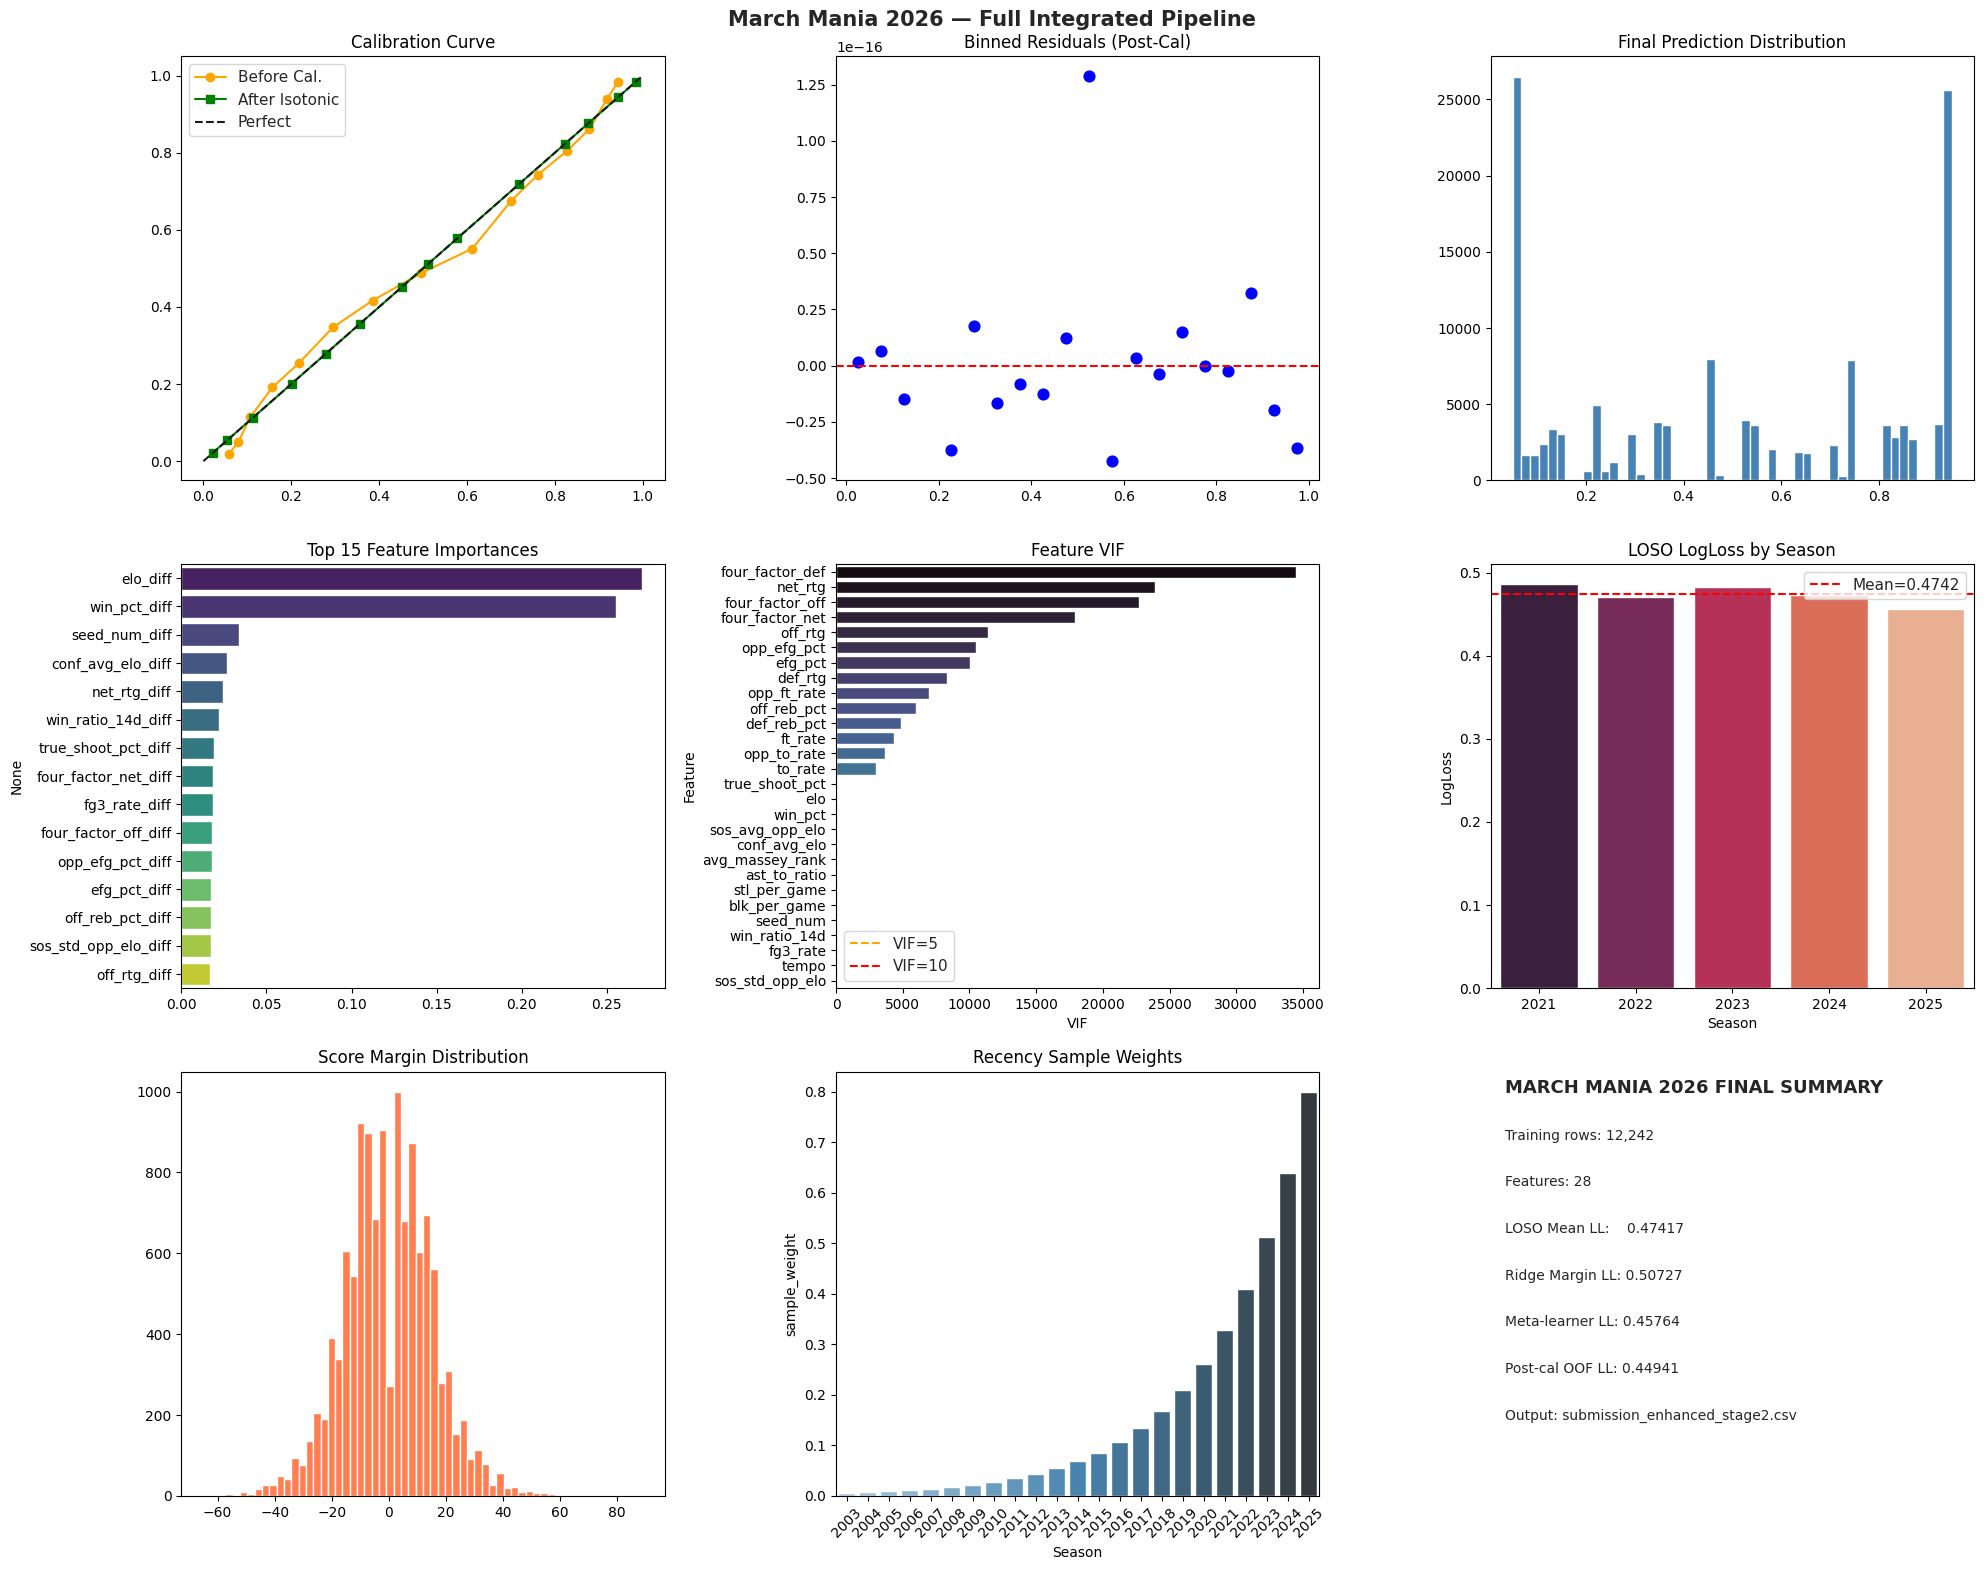


  PIPELINE COMPLETE | Post-cal OOF LogLoss: 0.44941


In [3]:
import re
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression, Ridge
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import calibration_curve
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================
DATA_PATH      = '/kaggle/input/competitions/march-machine-learning-mania-2025/'
OUTPUT_FILE    = 'submission_enhanced_stage2.csv'
ELO_K          = 32
ELO_HOME_ADV   = 100
ELO_INIT       = 1500
ELO_CARRYOVER  = 0.75
CLIP_LOW, CLIP_HIGH = 0.05, 0.95
SEEDS          = [42, 123, 2026]
MIN_SEASON     = 2003
VIF_THRESHOLD  = 15.0
MARGIN_SCALE   = 11.0
RECENCY_DECAY  = 0.80
LOSO_VAL_YEARS = [2025, 2024, 2023, 2022, 2021]
OPTUNA_TRIALS  = 60
SHRINK_PRIOR   = 10

CORE_FEATURES = [
    "elo", "seed_num", "avg_massey_rank",
    "sos_avg_opp_elo", "sos_std_opp_elo",
    "net_rtg", "off_rtg", "def_rtg", "tempo",
    "efg_pct", "opp_efg_pct",
    "to_rate", "opp_to_rate",
    "off_reb_pct", "def_reb_pct",
    "ft_rate", "opp_ft_rate",
    "four_factor_off", "four_factor_def", "four_factor_net",
    "true_shoot_pct", "fg3_rate", "ast_to_ratio",
    "blk_per_game", "stl_per_game",
    "conf_avg_elo", "win_pct", "win_ratio_14d",
]

print("=" * 65)
print("  MARCH MANIA 2026 - FULL INTEGRATED PIPELINE")
print("=" * 65)

# ============================================================
# 1. LOAD DATA
# ============================================================
print("\n---> 1. Loading Data...")

def load_csv(filename):
    try:
        return pd.read_csv(DATA_PATH + filename)
    except FileNotFoundError:
        print(f"   WARNING: {filename} not found")
        return pd.DataFrame()

data = {
    "m_reg_compact":     load_csv("MRegularSeasonCompactResults.csv"),
    "w_reg_compact":     load_csv("WRegularSeasonCompactResults.csv"),
    "m_reg_detail":      load_csv("MRegularSeasonDetailedResults.csv"),
    "w_reg_detail":      load_csv("WRegularSeasonDetailedResults.csv"),
    "m_tourney_compact": load_csv("MNCAATourneyCompactResults.csv"),
    "w_tourney_compact": load_csv("WNCAATourneyCompactResults.csv"),
    "m_seeds":           load_csv("MNCAATourneySeeds.csv"),
    "w_seeds":           load_csv("WNCAATourneySeeds.csv"),
    "m_conferences":     load_csv("MTeamConferences.csv"),
    "w_conferences":     load_csv("WTeamConferences.csv"),
    "massey":            load_csv("MMasseyOrdinals.csv"),
    "stage2":            load_csv("SampleSubmissionStage2.csv"),
}
for k, v in data.items():
    if len(v) > 0:
        print(f"   {k:25s}: {len(v):,} rows")

# ============================================================
# 2. ELO RATINGS
# ============================================================
print("\n---> 2. Computing Elo Ratings...")

def compute_elo_ratings(compact_df):
    if len(compact_df) == 0:
        return {}
    df = compact_df.sort_values(["Season","DayNum"]).reset_index(drop=True)
    elo, season_elo, prev_season = {}, {}, None
    for _, row in df.iterrows():
        s = row["Season"]
        w, l = row["WTeamID"], row["LTeamID"]
        loc  = row.get("WLoc", "N")
        ws, ls = row["WScore"], row["LScore"]
        if s != prev_season:
            if prev_season is not None:
                for t, r in elo.items(): season_elo[(prev_season, t)] = r
                for t in elo: elo[t] = ELO_INIT + ELO_CARRYOVER*(elo[t]-ELO_INIT)
            prev_season = s
        for t in [w, l]:
            if t not in elo: elo[t] = ELO_INIT
        if row["DayNum"] <= 132:
            wa = elo[w]+ELO_HOME_ADV if loc=="H" else elo[w]
            la = elo[l]+ELO_HOME_ADV if loc=="A" else elo[l]
            we = 1.0/(1.0+10.0**((la-wa)/400.0))
            mov = abs(ws-ls)
            mm  = np.log(max(mov,1)+1)*(2.2/((elo[w]-elo[l])*0.001+2.2))
            k   = ELO_K*mm
            elo[w] += k*(1-we); elo[l] -= k*(1-we)
    if prev_season is not None:
        for t, r in elo.items(): season_elo[(prev_season, t)] = r
    return season_elo

m_elo = compute_elo_ratings(data["m_reg_compact"])
w_elo = compute_elo_ratings(data["w_reg_compact"])
print(f"   Men Elo: {len(m_elo):,} | Women Elo: {len(w_elo):,}")

# ============================================================
# 3. STRENGTH OF SCHEDULE
# ============================================================
print("\n---> 3. Computing Strength of Schedule...")

def compute_sos(compact_df, season_elo):
    if len(compact_df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","sos_avg_opp_elo","sos_std_opp_elo"])
    records = []
    for _, row in compact_df[compact_df["DayNum"] <= 132].iterrows():
        s, w, l = row["Season"], row["WTeamID"], row["LTeamID"]
        records.append({"Season":s,"TeamID":w,"opp_elo":season_elo.get((s,l),ELO_INIT)})
        records.append({"Season":s,"TeamID":l,"opp_elo":season_elo.get((s,w),ELO_INIT)})
    df  = pd.DataFrame(records)
    agg = df.groupby(["Season","TeamID"])["opp_elo"].agg(
        sos_avg_opp_elo="mean", sos_std_opp_elo="std").reset_index()
    agg["sos_std_opp_elo"] = agg["sos_std_opp_elo"].fillna(0)
    return agg

m_sos = compute_sos(data["m_reg_compact"], m_elo)
w_sos = compute_sos(data["w_reg_compact"], w_elo)
print(f"   Men SOS: {len(m_sos):,} | Women SOS: {len(w_sos):,}")

# ============================================================
# 4. ADVANCED STATS — POSSESSION-ADJUSTED + FOUR FACTORS
# ============================================================
print("\n---> 4. Computing Advanced Stats...")

def shrink_toward_mean(values, n_games, prior=SHRINK_PRIOR):
    """Bayesian shrinkage: pulls small-sample teams toward population mean."""
    pop_mean = values.mean()
    weight   = n_games / (n_games + prior)
    return weight * values + (1 - weight) * pop_mean

def compute_four_factors(agg):
    """Dean Oliver's Four Factors with standard weights."""
    agg["four_factor_off"] = (
        0.40*agg["efg_pct"] - 0.25*agg["to_rate"]
      + 0.20*agg["off_reb_pct"] + 0.15*agg["ft_rate"])
    agg["four_factor_def"] = (
      - 0.40*agg["opp_efg_pct"] + 0.25*agg["opp_to_rate"]
      - 0.20*agg["def_reb_pct"] - 0.15*agg["opp_ft_rate"])
    agg["four_factor_net"] = agg["four_factor_off"] + agg["four_factor_def"]
    return agg

def compute_advanced_stats(detail_df, compact_df):
    all_stats = []
    if len(detail_df) > 0:
        df = detail_df[detail_df["DayNum"] <= 132].copy()

        def stack_side(df, us, them, tcol):
            cols = {
                f"{us}Score":"pts_for",   f"{them}Score":"pts_against",
                f"{us}FGM":"fgm",         f"{us}FGA":"fga",
                f"{us}FGM3":"fgm3",       f"{us}FGA3":"fga3",
                f"{us}FTM":"ftm",         f"{us}FTA":"fta",
                f"{us}OR":"off_reb",      f"{us}DR":"def_reb",
                f"{us}Ast":"ast",         f"{us}TO":"to_",
                f"{us}Stl":"stl",         f"{us}Blk":"blk",
                f"{them}FGM":"opp_fgm",   f"{them}FGA":"opp_fga",
                f"{them}FGM3":"opp_fgm3",
                f"{them}OR":"opp_or",     f"{them}DR":"opp_dr",
                f"{them}TO":"opp_to",     f"{them}FTA":"opp_fta",
            }
            av = {k:v for k,v in cols.items() if k in df.columns}
            s  = df[["Season",tcol]+list(av.keys())].copy()
            return s.rename(columns={**av, tcol:"TeamID"})

        combined = pd.concat([
            stack_side(df,"W","L","WTeamID"),
            stack_side(df,"L","W","LTeamID")], ignore_index=True)

        combined["poss"] = (combined["fga"]+0.475*combined["fta"]
                            -combined["off_reb"]+combined["to_"]).clip(lower=1)

        agg = combined.groupby(["Season","TeamID"]).agg(
            games=("pts_for","count"),
            wins=("pts_for", lambda x: (x>combined.loc[x.index,"pts_against"]).sum()),
            total_pts=("pts_for","sum"),     total_opp_pts=("pts_against","sum"),
            total_poss=("poss","sum"),
            total_fgm=("fgm","sum"),         total_fga=("fga","sum"),
            total_fgm3=("fgm3","sum"),       total_fga3=("fga3","sum"),
            total_ftm=("ftm","sum"),         total_fta=("fta","sum"),
            total_or=("off_reb","sum"),      total_dr=("def_reb","sum"),
            total_ast=("ast","sum"),         total_to=("to_","sum"),
            total_stl=("stl","sum"),         total_blk=("blk","sum"),
            total_opp_fgm=("opp_fgm","sum"),total_opp_fga=("opp_fga","sum"),
            total_opp_fgm3=("opp_fgm3","sum"),
            total_opp_or=("opp_or","sum"),   total_opp_dr=("opp_dr","sum"),
            total_opp_to=("opp_to","sum"),   total_opp_fta=("opp_fta","sum"),
        ).reset_index()

        g = agg["games"]; p = agg["total_poss"].clip(lower=1)
        agg["win_pct"]        = agg["wins"]/g
        agg["tempo"]          = p/g
        agg["off_rtg"]        = 100*agg["total_pts"]/p
        agg["def_rtg"]        = 100*agg["total_opp_pts"]/p
        agg["net_rtg"]        = agg["off_rtg"]-agg["def_rtg"]
        agg["efg_pct"]        = (agg["total_fgm"]+0.5*agg["total_fgm3"])/agg["total_fga"].replace(0,1)
        agg["true_shoot_pct"] = agg["total_pts"]/(2*(agg["total_fga"]+0.475*agg["total_fta"])).replace(0,1)
        agg["fg3_rate"]       = agg["total_fga3"]/agg["total_fga"].replace(0,1)
        agg["ft_rate"]        = agg["total_fta"]/agg["total_fga"].replace(0,1)
        agg["to_rate"]        = agg["total_to"]/p
        agg["ast_to_ratio"]   = agg["total_ast"]/agg["total_to"].replace(0,1)
        agg["off_reb_pct"]    = agg["total_or"]/(agg["total_or"]+agg["total_opp_dr"]).replace(0,1)
        agg["def_reb_pct"]    = agg["total_dr"]/(agg["total_dr"]+agg["total_opp_or"]).replace(0,1)
        agg["opp_efg_pct"]    = (agg["total_opp_fgm"]+0.5*agg["total_opp_fgm3"])/agg["total_opp_fga"].replace(0,1)
        agg["opp_to_rate"]    = agg["total_opp_to"]/p
        agg["opp_ft_rate"]    = agg["total_opp_fta"]/agg["total_opp_fga"].replace(0,1)
        agg["blk_per_game"]   = agg["total_blk"]/g
        agg["stl_per_game"]   = agg["total_stl"]/g

        # Bayesian shrinkage on rate stats
        for col in ["efg_pct","to_rate","off_reb_pct","def_reb_pct",
                    "opp_efg_pct","opp_to_rate","ft_rate","opp_ft_rate"]:
            agg[col] = shrink_toward_mean(agg[col], agg["games"])

        agg = compute_four_factors(agg)

        stat_cols = [
            "Season","TeamID","games","wins","win_pct",
            "tempo","off_rtg","def_rtg","net_rtg",
            "efg_pct","true_shoot_pct","fg3_rate","ft_rate",
            "to_rate","ast_to_ratio","off_reb_pct","def_reb_pct",
            "opp_efg_pct","opp_to_rate","opp_ft_rate",
            "blk_per_game","stl_per_game",
            "four_factor_off","four_factor_def","four_factor_net",
        ]
        all_stats.append(agg[stat_cols])

    # Compact fallback for older seasons without detailed data
    seasons_done = set(all_stats[0]["Season"].unique()) if all_stats else set()
    if len(compact_df) > 0:
        cdf  = compact_df[compact_df["DayNum"] <= 132]
        miss = cdf[~cdf["Season"].isin(seasons_done)]
        if len(miss) > 0:
            wc = miss.groupby(["Season","WTeamID"]).agg(
                wg=("WScore","count"),wp=("WScore","sum"),wo=("LScore","sum")
            ).reset_index().rename(columns={"WTeamID":"TeamID"})
            lc = miss.groupby(["Season","LTeamID"]).agg(
                lg=("LScore","count"),lp=("LScore","sum"),lo=("WScore","sum")
            ).reset_index().rename(columns={"LTeamID":"TeamID"})
            mc = pd.merge(wc, lc, on=["Season","TeamID"], how="outer").fillna(0)
            mc["games"]   = mc["wg"]+mc["lg"]
            mc["wins"]    = mc["wg"]
            mc["win_pct"] = mc["wins"]/mc["games"]
            mc["off_rtg"] = (mc["wp"]+mc["lp"])/mc["games"]
            mc["def_rtg"] = (mc["wo"]+mc["lo"])/mc["games"]
            mc["net_rtg"] = mc["off_rtg"]-mc["def_rtg"]
            for col in ["tempo","efg_pct","true_shoot_pct","fg3_rate","ft_rate",
                        "to_rate","ast_to_ratio","off_reb_pct","def_reb_pct",
                        "opp_efg_pct","opp_to_rate","opp_ft_rate","blk_per_game",
                        "stl_per_game","four_factor_off","four_factor_def","four_factor_net"]:
                mc[col] = np.nan
            sc = [
                "Season","TeamID","games","wins","win_pct","tempo","off_rtg","def_rtg",
                "net_rtg","efg_pct","true_shoot_pct","fg3_rate","ft_rate","to_rate",
                "ast_to_ratio","off_reb_pct","def_reb_pct","opp_efg_pct","opp_to_rate",
                "opp_ft_rate","blk_per_game","stl_per_game",
                "four_factor_off","four_factor_def","four_factor_net",
            ]
            all_stats.append(mc[sc])

    return pd.concat(all_stats, ignore_index=True) if all_stats else pd.DataFrame()

m_stats = compute_advanced_stats(data["m_reg_detail"], data["m_reg_compact"])
w_stats = compute_advanced_stats(data["w_reg_detail"], data["w_reg_compact"])
print(f"   Men: {len(m_stats):,} | Women: {len(w_stats):,}")

# ============================================================
# 5. MASSEY + SEEDS + CONFERENCE + MOMENTUM
# ============================================================
print("\n---> 5. Supporting Features...")

def compute_massey_features(massey_df):
    if massey_df is None or len(massey_df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","avg_massey_rank"])
    col   = "RankingDayNum" if "RankingDayNum" in massey_df.columns else "DayNum"
    final = massey_df[massey_df[col] == 133]
    sys_  = [s for s in ["POM","SAG","MOR","DOL","COL","KPK"]
              if s in final["SystemName"].unique()]
    if not sys_: sys_ = list(final["SystemName"].unique())[:6]
    return (final[final["SystemName"].isin(sys_)]
            .groupby(["Season","TeamID"])
            .agg(avg_massey_rank=("OrdinalRank","mean"))
            .reset_index())

def process_seeds(df):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","seed_num"])
    d = df.copy()
    d["seed_num"] = d["Seed"].apply(lambda x: int(re.findall(r"\d+",x)[0]))
    return d[["Season","TeamID","seed_num"]]

def compute_conf_strength(conf_df, season_elo):
    if conf_df is None or len(conf_df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","conf_avg_elo"])
    df = conf_df.copy()
    df["team_elo"] = df.apply(lambda r: season_elo.get((r["Season"],r["TeamID"]),ELO_INIT), axis=1)
    cs = df.groupby(["Season","ConfAbbrev"])["team_elo"].mean().reset_index(name="conf_avg_elo")
    return pd.merge(df[["Season","TeamID","ConfAbbrev"]], cs,
                    on=["Season","ConfAbbrev"])[["Season","TeamID","conf_avg_elo"]]

def compute_momentum(compact_df, threshold=118):
    if len(compact_df) == 0:
        return pd.DataFrame(columns=["Season","TeamID","win_ratio_14d"])
    late = compact_df[compact_df["DayNum"] >= threshold]
    w = late.groupby(["Season","WTeamID"]).size().reset_index(name="w").rename(columns={"WTeamID":"TeamID"})
    l = late.groupby(["Season","LTeamID"]).size().reset_index(name="l").rename(columns={"LTeamID":"TeamID"})
    mom = pd.merge(w, l, on=["Season","TeamID"], how="outer").fillna(0)
    mom["win_ratio_14d"] = mom["w"]/(mom["w"]+mom["l"]).replace(0,1)
    return mom[["Season","TeamID","win_ratio_14d"]]

massey_feats = compute_massey_features(data["massey"])
m_seeds = process_seeds(data["m_seeds"]); w_seeds = process_seeds(data["w_seeds"])
m_conf  = compute_conf_strength(data["m_conferences"], m_elo)
w_conf  = compute_conf_strength(data["w_conferences"], w_elo)
m_mom   = compute_momentum(data["m_reg_compact"])
w_mom   = compute_momentum(data["w_reg_compact"])
print(f"   Massey: {len(massey_feats):,} | M-Seeds: {len(m_seeds):,} | W-Seeds: {len(w_seeds):,}")

# ============================================================
# 6. UNIFIED TEAM FEATURES
# ============================================================
print("\n---> 6. Building Team Feature Tables...")

def build_team_features(stats_df, season_elo, seeds_df, massey_df,
                         conf_df, mom_df, sos_df):
    elo_df = pd.DataFrame(
        [(s,t,e) for (s,t),e in season_elo.items()],
        columns=["Season","TeamID","elo"])
    feat = elo_df.copy()
    for df in [stats_df, seeds_df, massey_df, conf_df, mom_df, sos_df]:
        if df is not None and len(df) > 0:
            feat = feat.merge(df, on=["Season","TeamID"], how="left")

    feat["seed_num"]        = feat["seed_num"].fillna(20)
    feat["conf_avg_elo"]    = feat["conf_avg_elo"].fillna(ELO_INIT)
    feat["win_ratio_14d"]   = feat["win_ratio_14d"].fillna(0.5)
    feat["sos_avg_opp_elo"] = feat["sos_avg_opp_elo"].fillna(ELO_INIT)
    feat["sos_std_opp_elo"] = feat["sos_std_opp_elo"].fillna(0)

    if "avg_massey_rank" not in feat.columns:
        feat["avg_massey_rank"] = 300.0
    else:
        feat["avg_massey_rank"] = feat["avg_massey_rank"].fillna(
            feat["avg_massey_rank"].max() if feat["avg_massey_rank"].notna().any() else 300)

    for col in [c for c in CORE_FEATURES if c in feat.columns]:
        feat[col] = feat.groupby("Season")[col].transform(lambda x: x.fillna(x.median()))
    return feat

m_features = build_team_features(m_stats,m_elo,m_seeds,massey_feats,m_conf,m_mom,m_sos)
w_features = build_team_features(w_stats,w_elo,w_seeds,None,        w_conf,w_mom,w_sos)
print(f"   Men: {len(m_features):,} | Women: {len(w_features):,}")

# ============================================================
# 7. VIF CHECK
# ============================================================
print("\n---> 7. VIF Check...")

def check_vif(features_df, feature_list, label=""):
    avail  = [f for f in feature_list if f in features_df.columns]
    sample = features_df[avail].dropna().sample(min(3000,len(features_df)),random_state=42)
    Xc     = sm.add_constant(sample)
    vdf    = pd.DataFrame({
        "Feature": Xc.columns,
        "VIF":     [variance_inflation_factor(Xc.values,i) for i in range(Xc.shape[1])]
    }).query("Feature != 'const'").sort_values("VIF", ascending=False)
    high = vdf[vdf["VIF"] > VIF_THRESHOLD]
    print(f"\n   {label} VIF:\n" + vdf.to_string(index=False))
    if len(high): print(f"   WARNING: {list(high['Feature'])} above threshold")
    else:         print(f"   All VIF <= {VIF_THRESHOLD}")
    return vdf

check_vif(m_features, CORE_FEATURES, "Men's")

# ============================================================
# 8. BUILD TRAINING DATA (carries margin through)
# ============================================================
print("\n---> 8. Building Training Data...")

def build_matchup_row(r1, r2):
    return {f"{col}_diff": (r1.get(col,np.nan)-r2.get(col,np.nan))
            for col in CORE_FEATURES
            if pd.notna(r1.get(col)) and pd.notna(r2.get(col))}

def build_training_data(features_df, tourney_df, reg_df=None, frac=0.15):
    fidx = features_df.set_index(["Season","TeamID"]).to_dict("index")
    rows = []

    def add_game(season, wid, lid, ws, ls):
        t1, t2 = min(wid,lid), max(wid,lid)
        r1, r2 = fidx.get((season,t1)), fidx.get((season,t2))
        if r1 is None or r2 is None: return
        feat = build_matchup_row(r1, r2)
        feat["target"] = 1.0 if wid==t1 else 0.0
        feat["margin"] = (ws-ls) if wid==t1 else -(ws-ls)
        feat["Season"] = season
        rows.append(feat)

    for _, row in tourney_df.iterrows():
        add_game(row["Season"],row["WTeamID"],row["LTeamID"],row["WScore"],row["LScore"])
    if reg_df is not None and len(reg_df) > 0:
        for _, row in reg_df[reg_df["DayNum"]>=100].sample(frac=frac,random_state=42).iterrows():
            add_game(row["Season"],row["WTeamID"],row["LTeamID"],row["WScore"],row["LScore"])
    return pd.DataFrame(rows)

all_features_df = pd.concat([m_features, w_features], ignore_index=True)
m_train = build_training_data(
    m_features,
    data["m_tourney_compact"][data["m_tourney_compact"]["Season"] < 2025],  # CHANGED
    data["m_reg_compact"]
)
w_train = build_training_data(
    w_features,
    data["w_tourney_compact"][data["w_tourney_compact"]["Season"] < 2025],  # CHANGED
    data["w_reg_compact"]
)
all_train = pd.concat([m_train, w_train], ignore_index=True)
all_train = all_train[all_train["Season"] >= MIN_SEASON].reset_index(drop=True)

feature_cols = [c for c in all_train.columns if c.endswith("_diff")]
medians = all_train[feature_cols].median()
all_train[feature_cols] = all_train[feature_cols].fillna(medians)

# Recency weights — exponential decay
all_train["sample_weight"] = all_train["Season"].apply(lambda s: RECENCY_DECAY**(2026-s))
print(f"   Rows: {len(all_train):,} | Features: {len(feature_cols)} | Balance: {all_train['target'].mean():.3f}")

# ============================================================
# 9. BUILD PREDICTION GRID
# ============================================================
print("\n---> 9. Building Prediction Grid...")

feat_idx_all = all_features_df.set_index(["Season","TeamID"]).to_dict("index")
sample_sub   = data["stage2"].copy()
sub_parsed   = sample_sub["ID"].str.split("_", expand=True).astype(int)
sub_parsed.columns = ["Season","T1","T2"]

pred_rows = []
for _, row in sub_parsed.iterrows():
    s,t1,t2 = row["Season"],row["T1"],row["T2"]
    r1,r2   = feat_idx_all.get((s,t1)), feat_idx_all.get((s,t2))
    if r1 and r2: pred_rows.append(build_matchup_row(r1,r2))
    else:         pred_rows.append({f"{c}_diff":0.0 for c in CORE_FEATURES})

pred_df = pd.DataFrame(pred_rows).fillna(medians)
X_pred  = pred_df[feature_cols].fillna(0).values
print(f"   Prediction rows: {len(pred_df):,}")

X_all = all_train[feature_cols].values
y_all = all_train["target"].values
w_all = all_train["sample_weight"].values

# ============================================================
# 10. LOSO VALIDATION
# ============================================================
print("\n---> 10. Leave-One-Season-Out Validation...")

def loso_cv(train_df, fcols, val_seasons=LOSO_VAL_YEARS):
    results = {}
    for yr in val_seasons:
        tr = train_df[train_df["Season"] != yr]
        va = train_df[train_df["Season"] == yr]
        if len(va) < 10: continue
        m = xgb.XGBClassifier(n_estimators=400, learning_rate=0.03,
                                max_depth=4, verbosity=0, random_state=42)
        m.fit(tr[fcols], tr["target"], sample_weight=tr["sample_weight"])
        p  = m.predict_proba(va[fcols])[:, 1]
        ll = log_loss(va["target"], p)
        results[yr] = ll
        print(f"   {yr}: LogLoss = {ll:.5f}  (n={len(va)})")
    mean_ll = np.mean(list(results.values()))
    print(f"   Mean LOSO LogLoss: {mean_ll:.5f}")
    return results, mean_ll

loso_scores, loso_mean = loso_cv(all_train, feature_cols)

# ============================================================
# 11. OPTUNA HYPERPARAMETER TUNING
# ============================================================
print(f"\n---> 11. Optuna Tuning ({OPTUNA_TRIALS} trials each)...")

loso_splits = [(all_train.index[all_train["Season"]!=yr].tolist(),
                all_train.index[all_train["Season"]==yr].tolist())
               for yr in LOSO_VAL_YEARS
               if (all_train["Season"]==yr).sum() >= 10]

def xgb_obj(trial):
    p = dict(
        n_estimators=trial.suggest_int("n_estimators",300,1200),
        learning_rate=trial.suggest_float("learning_rate",0.005,0.05,log=True),
        max_depth=trial.suggest_int("max_depth",3,6),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),
        min_child_weight=trial.suggest_int("min_child_weight",5,40),
        gamma=trial.suggest_float("gamma",0.0,1.0),
        reg_alpha=trial.suggest_float("reg_alpha",0.0,2.0),
        reg_lambda=trial.suggest_float("reg_lambda",0.5,3.0),
    )
    scores = []
    for ti,vi in loso_splits:
        m = xgb.XGBClassifier(**p, verbosity=0, random_state=42, tree_method="hist")
        m.fit(X_all[ti], y_all[ti], sample_weight=w_all[ti])
        scores.append(log_loss(y_all[vi], m.predict_proba(X_all[vi])[:,1]))
    return np.mean(scores)

def lgb_obj(trial):
    p = dict(
        n_estimators=trial.suggest_int("n_estimators",300,1500),
        learning_rate=trial.suggest_float("learning_rate",0.005,0.05,log=True),
        num_leaves=trial.suggest_int("num_leaves",8,32),
        min_child_samples=trial.suggest_int("min_child_samples",20,60),
        subsample=trial.suggest_float("subsample",0.6,1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree",0.5,1.0),
        reg_alpha=trial.suggest_float("reg_alpha",0.0,2.0),
        reg_lambda=trial.suggest_float("reg_lambda",0.5,3.0),
    )
    scores = []
    for ti,vi in loso_splits:
        m = lgb.LGBMClassifier(**p, verbose=-1, random_state=42)
        m.fit(X_all[ti], y_all[ti], sample_weight=w_all[ti])
        scores.append(log_loss(y_all[vi], m.predict_proba(X_all[vi])[:,1]))
    return np.mean(scores)

def cat_obj(trial):
    p = dict(
        iterations=trial.suggest_int("iterations",300,1200),
        learning_rate=trial.suggest_float("learning_rate",0.005,0.05,log=True),
        depth=trial.suggest_int("depth",3,7),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg",1.0,10.0),
        subsample=trial.suggest_float("subsample",0.6,1.0),
    )
    scores = []
    for ti,vi in loso_splits:
        m = CatBoostClassifier(**p, verbose=0, random_seed=42, eval_metric="Logloss")
        m.fit(X_all[ti], y_all[ti], sample_weight=w_all[ti])
        scores.append(log_loss(y_all[vi], m.predict_proba(X_all[vi])[:,1]))
    return np.mean(scores)

print("   Tuning XGBoost..."); xs=optuna.create_study(direction="minimize"); xs.optimize(xgb_obj,n_trials=OPTUNA_TRIALS); best_xgb=xs.best_params; print(f"   XGB: {xs.best_value:.5f}")
print("   Tuning LightGBM..."); ls=optuna.create_study(direction="minimize"); ls.optimize(lgb_obj,n_trials=OPTUNA_TRIALS); best_lgb=ls.best_params; print(f"   LGB: {ls.best_value:.5f}")
print("   Tuning CatBoost..."); cs=optuna.create_study(direction="minimize"); cs.optimize(cat_obj,n_trials=OPTUNA_TRIALS); best_cat=cs.best_params; print(f"   CAT: {cs.best_value:.5f}")

# ============================================================
# 12. MARGIN REGRESSION MODEL
# ============================================================
print("\n---> 12. Margin Regression Model...")

def margin_to_prob(m, scale=MARGIN_SCALE):
    return 1.0/(1.0+np.exp(-m/scale))

skf5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
ridge_oof  = np.zeros(len(X_all))
ridge_test = np.zeros(len(X_pred))

for fold, (ti, vi) in enumerate(skf5.split(X_all, y_all), 1):
    ridge = Ridge(alpha=10.0)
    ridge.fit(X_all[ti], all_train["margin"].values[ti], sample_weight=w_all[ti])
    ridge_oof[vi]  = ridge.predict(X_all[vi])
    ridge_test    += ridge.predict(X_pred)/5

ridge_oof_prob  = margin_to_prob(ridge_oof)
ridge_test_prob = margin_to_prob(ridge_test)
print(f"   Ridge OOF LogLoss: {log_loss(y_all, np.clip(ridge_oof_prob,1e-7,1-1e-7)):.5f}")

# ============================================================
# 13. MAIN ENSEMBLE (tuned + recency weights + all seeds)
# ============================================================
print("\n---> 13. Training Tuned Ensemble (5-Fold, 3 Seeds)...")

def train_ensemble(train_df, X_p, xp, lp, cp, seed=42):
    fc  = [c for c in train_df.columns if c.endswith("_diff")]
    X   = train_df[fc].values
    y   = train_df["target"].values
    sw  = train_df["sample_weight"].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    n   = skf.n_splits
    oof_x=np.zeros(len(X)); oof_l=np.zeros(len(X)); oof_c=np.zeros(len(X))
    tst_x=np.zeros(len(X_p)); tst_l=np.zeros(len(X_p)); tst_c=np.zeros(len(X_p))

    for fold,(ti,vi) in enumerate(skf.split(X,y),1):
        xm = xgb.XGBClassifier(**xp, verbosity=0, random_state=seed, tree_method="hist")
        xm.fit(X[ti],y[ti],sample_weight=sw[ti]); oof_x[vi]=xm.predict_proba(X[vi])[:,1]; tst_x+=xm.predict_proba(X_p)[:,1]/n
        lm = lgb.LGBMClassifier(**lp, verbose=-1, random_state=seed)
        lm.fit(X[ti],y[ti],sample_weight=sw[ti]); oof_l[vi]=lm.predict_proba(X[vi])[:,1]; tst_l+=lm.predict_proba(X_p)[:,1]/n
        cm = CatBoostClassifier(**cp, verbose=0, random_seed=seed)
        cm.fit(X[ti],y[ti],sample_weight=sw[ti]); oof_c[vi]=cm.predict_proba(X[vi])[:,1]; tst_c+=cm.predict_proba(X_p)[:,1]/n
        bl = (oof_x[vi]+oof_l[vi]+oof_c[vi])/3
        print(f"   Fold {fold} | XGB:{log_loss(y[vi],oof_x[vi]):.5f} LGB:{log_loss(y[vi],oof_l[vi]):.5f} CAT:{log_loss(y[vi],oof_c[vi]):.5f} BLEND:{log_loss(y[vi],bl):.5f}")
    return (oof_x,oof_l,oof_c),(tst_x,tst_l,tst_c)

all_ox,all_ol,all_oc = [],[],[]
all_tx,all_tl,all_tc = [],[],[]
for seed in SEEDS:
    print(f"\n   === Seed {seed} ===")
    (ox,ol,oc),(tx,tl,tc) = train_ensemble(all_train,X_pred,best_xgb,best_lgb,best_cat,seed)
    all_ox.append(ox); all_ol.append(ol); all_oc.append(oc)
    all_tx.append(tx); all_tl.append(tl); all_tc.append(tc)

oof_x=np.mean(all_ox,axis=0); oof_l=np.mean(all_ol,axis=0); oof_c=np.mean(all_oc,axis=0)
tst_x=np.mean(all_tx,axis=0); tst_l=np.mean(all_tl,axis=0); tst_c=np.mean(all_tc,axis=0)

# ============================================================
# 14. STACKING META-LEARNER
# ============================================================
print("\n---> 14. Stacking Meta-Learner...")

meta_Xtr = np.column_stack([oof_x, oof_l, oof_c, ridge_oof_prob])
meta_Xte = np.column_stack([tst_x, tst_l, tst_c, ridge_test_prob])

meta = LogisticRegression(C=0.5, max_iter=1000)
meta.fit(meta_Xtr, y_all)
final_oof   = meta.predict_proba(meta_Xtr)[:,1]
final_probs = meta.predict_proba(meta_Xte)[:,1]

meta_ll = log_loss(y_all, np.clip(final_oof,1e-7,1-1e-7))
print(f"   Meta OOF LogLoss: {meta_ll:.5f}")
print(f"   Weights — XGB:{meta.coef_[0][0]:.3f} LGB:{meta.coef_[0][1]:.3f} CAT:{meta.coef_[0][2]:.3f} Ridge:{meta.coef_[0][3]:.3f}")

# ============================================================
# 15. ISOTONIC CALIBRATION
# ============================================================
print("\n---> 15. Isotonic Calibration...")

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(final_oof, y_all)
cal_oof   = iso.predict(final_oof)
cal_preds = iso.predict(final_probs)
pre_ll  = log_loss(y_all, np.clip(final_oof,1e-7,1-1e-7))
post_ll = log_loss(y_all, np.clip(cal_oof,1e-7,1-1e-7))
print(f"   Pre-cal:  {pre_ll:.5f}")
print(f"   Post-cal: {post_ll:.5f}")

# ============================================================
# 16. SAVE SUBMISSION
# ============================================================
print("\n---> 16. Saving Submission...")
sample_sub["Pred"] = np.clip(cal_preds, CLIP_LOW, CLIP_HIGH)
sample_sub[["ID","Pred"]].to_csv(OUTPUT_FILE, index=False)
print(f"   Saved: {OUTPUT_FILE} ({len(sample_sub):,} rows)")
print(sample_sub["Pred"].describe().round(4))

# ============================================================
# 17. DIAGNOSTICS
# ============================================================
print("\n---> 17. Diagnostic Plots...")

fig, axes = plt.subplots(3, 3, figsize=(20,16))
sns.set_theme(style="whitegrid")

# Calibration
pt_r,pp_r = calibration_curve(y_all,np.clip(final_oof,1e-7,1-1e-7),n_bins=15,strategy='quantile')
pt_c,pp_c = calibration_curve(y_all,np.clip(cal_oof,1e-7,1-1e-7),  n_bins=15,strategy='quantile')
axes[0,0].plot(pp_r,pt_r,'o-',color='orange',label='Before Cal.')
axes[0,0].plot(pp_c,pt_c,'s-',color='green', label='After Isotonic')
axes[0,0].plot([0,1],[0,1],'--k',label='Perfect'); axes[0,0].set_title("Calibration Curve"); axes[0,0].legend()

# Binned residuals
res  = y_all - cal_oof
bins = np.linspace(0,1,21); bi = np.digitize(cal_oof,bins)-1
bm = [res[bi==i].mean() for i in range(len(bins)-1) if (bi==i).sum()>0]
bc = [(bins[i]+bins[i+1])/2 for i in range(len(bins)-1) if (bi==i).sum()>0]
axes[0,1].scatter(bc,bm,color='blue',s=60); axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Binned Residuals (Post-Cal)")

# Prediction distribution
axes[0,2].hist(np.clip(cal_preds,CLIP_LOW,CLIP_HIGH),bins=50,color='steelblue',edgecolor='w')
axes[0,2].set_title("Final Prediction Distribution")

# Feature importance
xmf = xgb.XGBClassifier(**best_xgb, verbosity=0, random_state=42, tree_method="hist")
xmf.fit(X_all, y_all, sample_weight=w_all)
imp = pd.Series(xmf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
sns.barplot(x=imp.values,y=imp.index,ax=axes[1,0],palette="viridis")
axes[1,0].set_title("Top 15 Feature Importances")

# VIF
vs   = m_features[CORE_FEATURES].dropna().sample(min(3000,len(m_features)),random_state=42)
Xv   = sm.add_constant(vs)
vbar = pd.DataFrame({"Feature":Xv.columns,"VIF":[variance_inflation_factor(Xv.values,i) for i in range(Xv.shape[1])]}).query("Feature!='const'").sort_values("VIF",ascending=False)
sns.barplot(x="VIF",y="Feature",data=vbar,ax=axes[1,1],palette="mako")
axes[1,1].axvline(5,color='orange',linestyle='--',label='VIF=5')
axes[1,1].axvline(10,color='red',linestyle='--',label='VIF=10')
axes[1,1].set_title("Feature VIF"); axes[1,1].legend()

# LOSO by year
ldf = pd.DataFrame(list(loso_scores.items()),columns=["Season","LogLoss"])
sns.barplot(x="Season",y="LogLoss",data=ldf,ax=axes[1,2],palette="rocket")
axes[1,2].axhline(loso_mean,color='red',linestyle='--',label=f'Mean={loso_mean:.4f}')
axes[1,2].set_title("LOSO LogLoss by Season"); axes[1,2].legend()

# Margin distribution
axes[2,0].hist(all_train["margin"],bins=60,color='coral',edgecolor='w')
axes[2,0].set_title("Score Margin Distribution")

# Recency weights
wd = all_train.groupby("Season")["sample_weight"].mean().reset_index()
sns.barplot(x="Season",y="sample_weight",data=wd,ax=axes[2,1],palette="Blues_d")
axes[2,1].set_title("Recency Sample Weights"); axes[2,1].tick_params(axis='x',rotation=45)

# Summary
axes[2,2].axis("off")
for i,(txt,sz,bold) in enumerate([
    ("MARCH MANIA 2026 FINAL SUMMARY",13,True),
    (f"Training rows: {len(all_train):,}",10,False),
    (f"Features: {len(feature_cols)}",10,False),
    (f"LOSO Mean LL:    {loso_mean:.5f}",10,False),
    (f"Ridge Margin LL: {log_loss(y_all,np.clip(ridge_oof_prob,1e-7,1-1e-7)):.5f}",10,False),
    (f"Meta-learner LL: {meta_ll:.5f}",10,False),
    (f"Post-cal OOF LL: {post_ll:.5f}",10,False),
    (f"Output: {OUTPUT_FILE}",10,False),
]):
    axes[2,2].text(0.03, 0.95-i*0.11, txt, fontsize=sz,
                   fontweight="bold" if bold else "normal",
                   transform=axes[2,2].transAxes)

plt.suptitle("March Mania 2026 — Full Integrated Pipeline",fontsize=15,fontweight="bold")
plt.tight_layout()
plt.savefig("diagnostics_final.png",dpi=150,bbox_inches="tight")
plt.show()

print("\n" + "="*65)
print(f"  PIPELINE COMPLETE | Post-cal OOF LogLoss: {post_ll:.5f}")
print("="*65)